In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [8]:
file_path = r"C:\Users\adity\OneDrive\Desktop\Ecommerce-Analytics\data\online_retail_II.xlsx"

df = pd.read_excel(file_path)

print("Shape:", df.shape)
df.head()

Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   UnitPrice    400916 non-null  float64       
 6   CustomerID   400916 non-null  float64       
 7   Country      400916 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.5+ MB


In [21]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [22]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,400916.0,19213.0,500356.0,251.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,400916,4017,85123A,3107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,400916,4444,WHITE HANGING HEART T-LIGHT HOLDER,3107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,400916.0,NaN,NaN,NaN,13.767418,1.0,2.0,5.0,12.0,19152.0,97.638385
InvoiceDate,400916,NaN,NaN,NaN,2010-07-01 05:01:16.167027712,2009-12-01 07:45:00,2010-03-26 13:28:00,2010-07-09 10:26:00,2010-10-14 13:58:45,2010-12-09 20:01:00,NaN
UnitPrice,400916.0,NaN,NaN,NaN,3.305826,0.001,1.25,1.95,3.75,10953.5,35.047719
CustomerID,400916.0,NaN,NaN,NaN,15361.544074,12346.0,13985.0,15311.0,16805.0,18287.0,1680.635823
Country,400916,37,United Kingdom,364233,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data Cleaning**

In [23]:
df.columns
df = df.rename(columns={
    "Invoice": "InvoiceNo",
    "StockCode": "StockCode",
    "Description": "Description",
    "Quantity": "Quantity",
    "InvoiceDate": "InvoiceDate",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
    "Country": "Country"
})

In [24]:
#Check missing values
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [25]:
#For our customer analysis, we need a customer ID
df = df.dropna(subset=["CustomerID"])

In [26]:
#Remove cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [27]:
#Remove invalid transactions
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [28]:
#Remove duplicates
df = df.drop_duplicates()

In [29]:
#Convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [30]:
#Create revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [31]:
print("Final shape:", df.shape)
df.head()

Final shape: (400916, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


**EDA**

In [32]:
print("Total Revenue:", df["Revenue"].sum())
print("Total Orders:", df["InvoiceNo"].nunique())
print("Total Customers:", df["CustomerID"].nunique())
print("Total Products:", df["StockCode"].nunique())

Total Revenue: 8798233.743999999
Total Orders: 19213
Total Customers: 4312
Total Products: 4017


In [34]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales.head(10)

,Month,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


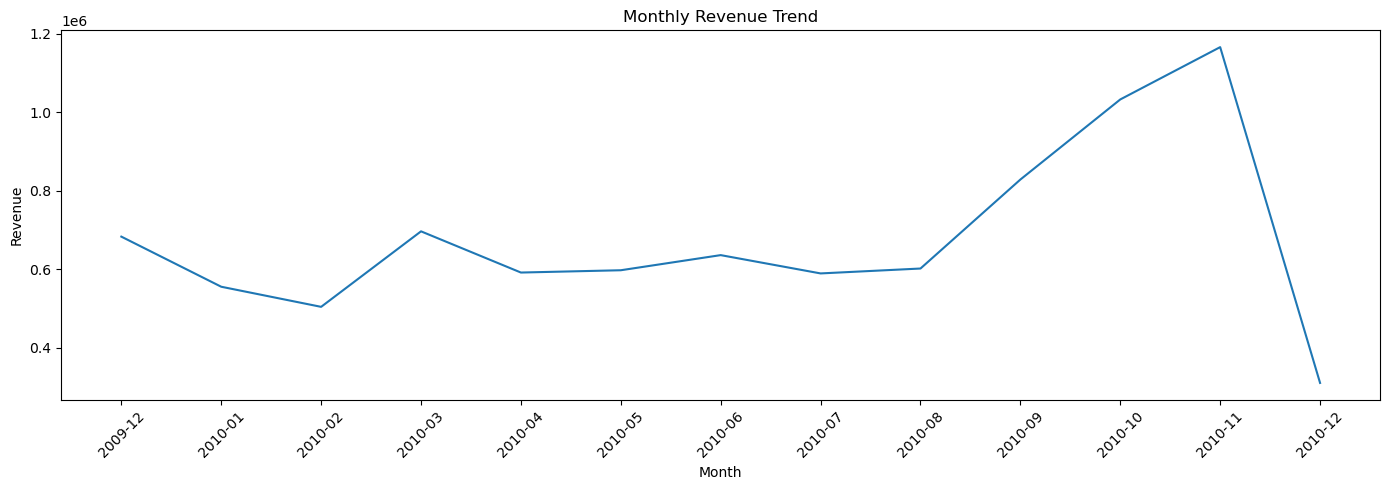

In [35]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

**Top Products**

In [36]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER     151339.16
REGENCY CAKESTAND 3 TIER               143727.60
Manual                                  98531.99
ASSORTED COLOUR BIRD ORNAMENT           70291.03
JUMBO BAG RED RETROSPOT                 51644.25
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40156.05
PAPER CHAIN KIT 50'S CHRISTMAS          36871.55
PARTY BUNTING                           35017.30
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

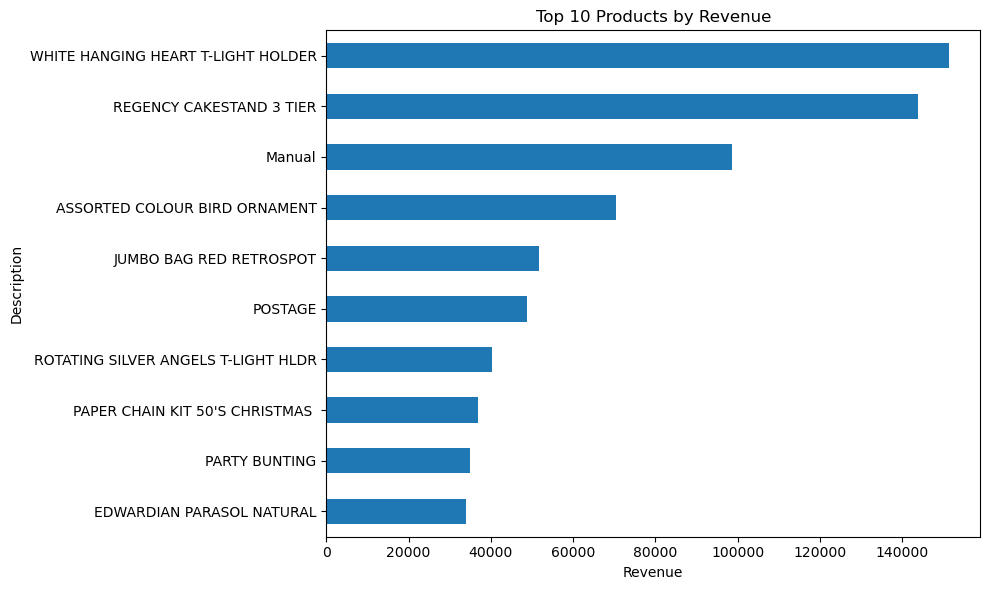

In [37]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.xlabel("Revenue")
plt.title("Top 10 Products by Revenue")
plt.tight_layout()
plt.show()

**Country analysis**<br>
Which markets generate the most revenue?

In [38]:
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

**RFM analysis**

In [39]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [40]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


**K-Means Clustering Model**

In [46]:
#log-transform the heavily skewed variables
rfm_log = np.log1p(rfm)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [49]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,13.827763,13.556555,7381.581077
1,23.947090,1.972487,532.078583
2,190.569666,1.298984,305.661388
3,80.214699,4.138728,1759.990102


In [50]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,13.83,13.56,7381.58
1,23.95,1.97,532.08
2,190.57,1.30,305.66
3,80.21,4.14,1759.99


In [56]:
segment_map = {
    0: "High-Value Loyal",
    1: "New / Occasional",
    2: "At-Risk / Lost",
    3: "Potential Loyalist"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(segment_map)

rfm.head(10)

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12346.0,165,11,372.86,3,Potential Loyalist
12347.0,3,2,1323.32,1,New / Occasional
12348.0,74,1,222.16,2,At-Risk / Lost
12349.0,43,3,2671.14,3,Potential Loyalist
12351.0,11,1,300.93,1,New / Occasional
12352.0,11,2,343.80,1,New / Occasional
12353.0,44,1,317.76,1,New / Occasional
12355.0,203,1,488.21,2,At-Risk / Lost
12356.0,16,3,3560.30,3,Potential Loyalist


In [52]:
rfm["CustomerSegment"].value_counts()

CustomerSegment
At-Risk / Lost        1378
Potential Loyalist    1211
New / Occasional       945
High-Value Loyal       778
Name: count, dtype: int64

In [57]:
rfm.groupby("CustomerSegment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

,Recency,Frequency,Monetary
CustomerSegment,,,
At-Risk / Lost,190.57,1.30,305.66
High-Value Loyal,13.83,13.56,7381.58
New / Occasional,23.95,1.97,532.08
Potential Loyalist,80.21,4.14,1759.99


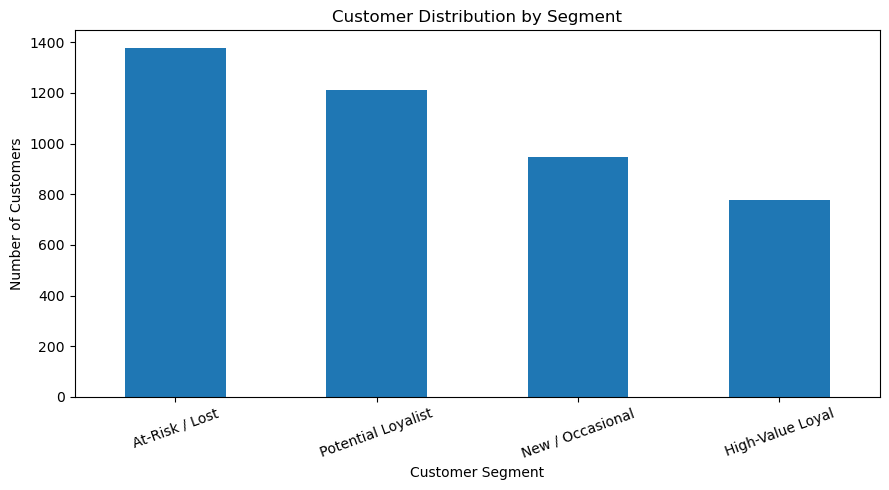

In [58]:
segment_counts = rfm["CustomerSegment"].value_counts()

plt.figure(figsize=(9, 5))
segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

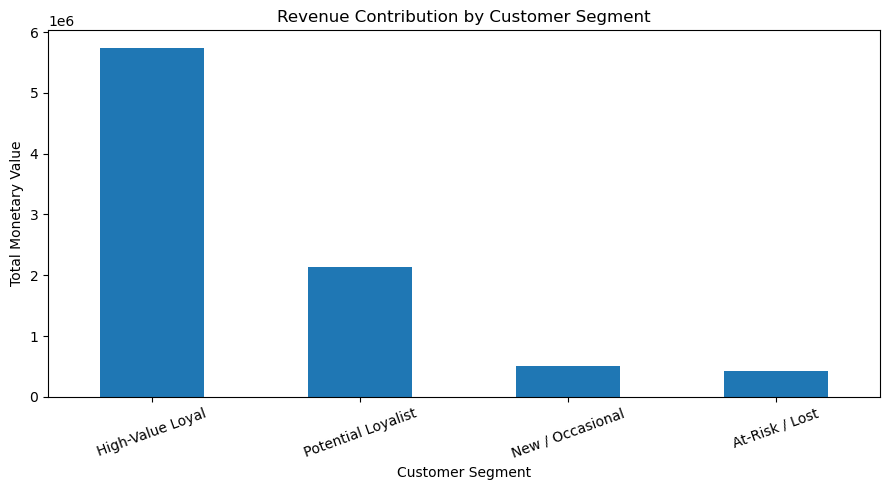

In [59]:
segment_revenue = (
    rfm.groupby("CustomerSegment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Monetary Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [61]:
import os

os.makedirs("../data/processed", exist_ok=True)
rfm_export = rfm.reset_index()
df.to_csv(
    "../data/processed/transactions_cleaned.csv",
    index=False
)

rfm.to_csv(
    "../data/processed/customer_rfm_segments.csv",
    index=True
)

print("Files saved successfully!")

Files saved successfully!
